# Maranatha.jl :: Merge and Fit Workflow

This notebook demonstrates how to:

1. run quadrature in multiple separate batches,
2. merge the saved `.jld2` result files,
3. perform a single extrapolation fit on the merged dataset.

This workflow is useful when the full set of sample points is generated
incrementally or across separate runs.

## Initialize environment

Set the Julia thread configuration and load the `Maranatha` package.

In [1]:
ENV["JULIA_NUM_THREADS"] = get(ENV, "JULIA_NUM_THREADS", "4")

using Maranatha

## Define common problem settings

We define the integrand, integration interval, quadrature rule,
boundary condition, error-estimation method, and shared output options.

These settings must remain consistent across all partial runs,
so that the resulting datasets can be merged safely afterward.

In [2]:
integrand(x) = sin(x)
bounds = (0.0, π)
dim = 1
rule = :gauss_p4
boundary = :LU_EXEX
err_method = :forwarddiff # :forwarddiff , :taylorseries , :enzyme , :fastdifferentiation
fit_terms = 4
nerr_terms = 3
ff_shift = 0
use_threads = true
result_string = "1D"
save_path = "."
write_summary = true
save_file = true

true

## Run the first batch

Here we compute the first subset of quadrature sample points.
This produces a saved result file containing only the selected `nsamples`.

In [3]:
ns = [2, 3]
run_result_part1 = run_Maranatha(
    integrand, 
    bounds...; 
    dim=dim, 
    nsamples=ns,
    rule=rule, 
    boundary=boundary, 
    err_method=err_method, 
    fit_terms=fit_terms, 
    nerr_terms=nerr_terms, 
    ff_shift=ff_shift, 
    use_threads=use_threads,
    name_prefix=result_string,
    save_path=save_path,
    write_summary=write_summary  
)

(a = 0.0, b = π, h = [1.5707963267948966, 1.0471975511965976], avg = [1.9999999543942306, 1.9999999983080423], err = NamedTuple[(ks = [8, 10, 12], coeffs = [1.1247885397696076e-9, 1.4753719807190856e-10, 3.815912407241898e-12], derivatives = [1.0, -1.0, 1.0], terms = [6.548619787326979e-8, -2.1194353746760364e-8, 1.3525608060985733e-9], total = 4.5644404932608e-8, center = 1.5707963267948966, h = 1.5707963267948966), (ks = [8, 10, 12], coeffs = [1.6871828099961932e-9, 5.72802215791421e-10, 5.0364674597346306e-11], derivatives = [1.0, -1.0, 1.0], terms = [2.555169434377858e-9, -9.513043596006897e-10, 9.172718506234212e-11], total = 1.6955922598395105e-9, center = 1.5707963267948966, h = 1.0471975511965976)], rule = :gauss_p4, boundary = :LU_EXEX, dim = 1, err_method = :forwarddiff, nerr_terms = 3, fit_terms = 4, ff_shift = 0, use_threads = true)

## Run the second batch

Next we compute another subset of sample points using the same numerical setup.

In [4]:
ns = [4, 5, 6]
run_result_part2 = run_Maranatha(
    integrand, 
    bounds...; 
    dim=dim, 
    nsamples=ns,
    rule=rule, 
    boundary=boundary, 
    err_method=err_method, 
    fit_terms=fit_terms, 
    nerr_terms=nerr_terms, 
    ff_shift=ff_shift, 
    use_threads=use_threads,
    name_prefix=result_string,
    save_path=save_path,
    write_summary=write_summary  
)

(a = 0.0, b = π, h = [0.7853981633974483, 0.6283185307179586, 0.5235987755982988], avg = [1.9999999998335218, 1.9999999999722913, 1.9999999999935836], err = NamedTuple[(ks = [8, 10, 12], coeffs = [2.2495770819334088e-9, 1.4198629360317195e-9, 2.489014012043227e-10], derivatives = [1.0, -1.0, 1.0], terms = [2.558054607147103e-10, -9.959444540804312e-11, 1.0769506414246399e-11], total = 1.669805217209136e-10, center = 1.5707963267948966, h = 0.7853981633974483), (ks = [8, 10, 12], coeffs = [2.811971365457476e-9, 2.8293179274730013e-9, 8.141204091629378e-10], derivatives = [1.0, -1.0, 1.0], terms = [4.291703488293286e-11, -1.7047484464908643e-11, 1.936542046313519e-12], total = 2.7806092464337738e-11, center = 1.5707963267948966, h = 0.6283185307179586), (ks = [8, 10, 11], coeffs = [3.3743656926855604e-9, 4.941765760435297e-9, -4.556951968960078e-19], derivatives = [1.0, -1.0, -6.123233995736766e-17], terms = [9.981130818059683e-12, -4.0074397478182994e-12, 1.1847828931183237e-38], total 

## Run the third batch

Finally we compute the remaining subset of sample points.
All partial runs together will form the complete dataset.

In [5]:
ns = [7, 8, 9]
run_result_part3 = run_Maranatha(
    integrand, 
    bounds...; 
    dim=dim, 
    nsamples=ns,
    rule=rule, 
    boundary=boundary, 
    err_method=err_method, 
    fit_terms=fit_terms, 
    nerr_terms=nerr_terms, 
    ff_shift=ff_shift, 
    use_threads=use_threads,
    name_prefix=result_string,
    save_path=save_path,
    write_summary=write_summary  
)

(a = 0.0, b = π, h = [0.4487989505128276, 0.39269908169872414, 0.3490658503988659], avg = [1.9999999999981353, 1.9999999999993598, 1.9999999999997509], err = NamedTuple[(ks = [8, 10, 11], coeffs = [3.936760177812031e-9, 7.897805015065189e-9, 7.291123150336125e-19], derivatives = [1.0, -1.0, -6.123233995736766e-17], terms = [2.9080739967645065e-12, -1.1751047098474008e-12, -2.981242349828409e-39], total = 1.7329692869171057e-12, center = 1.5707963267948966, h = 0.4487989505128276), (ks = [8, 9, 10], coeffs = [4.499154617824677e-9, 8.020235465369738e-17, 1.1838034271540587e-8], derivatives = [1.0, 6.123233995736766e-17, -1.0], terms = [9.99240181738652e-13, 4.283184990592302e-37, -4.054509624373003e-13], total = 5.937892193013518e-13, center = 1.5707963267948966, h = 0.39269908169872414), (ks = [8, 9, 10], coeffs = [5.061549508975568e-9, 6.41618837229579e-16, 1.6903052131343155e-8], derivatives = [1.0, 6.123233995736766e-17, -1.0], terms = [3.894482516494075e-13, 1.0551922540456496e-36, 

## Merge saved result files

The function `merge_datapoint_result_files` combines multiple saved
quadrature result files into a single merged dataset.

This is convenient when data points were produced in separate sessions
but should be analyzed together in one fit.

In [6]:
merged_file = merge_datapoint_result_files(
    "result_$(result_string)_$(rule)_$(boundary)_N_2_3.jld2",
    "result_$(result_string)_$(rule)_$(boundary)_N_4_5_6.jld2",
    "result_$(result_string)_$(rule)_$(boundary)_N_7_8_9.jld2";
    output_path = "result_merged.jld2",
    write_summary=true
)

"result_merged.jld2"

## Load merged dataset

Load the merged `.jld2` file as a single quadrature result object.

In [7]:
run_result_merged = load_datapoint_results(merged_file)

(a = 0.0, b = 3.141592653589793, h = [1.5707963267948966, 1.0471975511965976, 0.7853981633974483, 0.6283185307179586, 0.5235987755982988, 0.4487989505128276, 0.39269908169872414, 0.3490658503988659], avg = [1.9999999543942306, 1.9999999983080423, 1.9999999998335218, 1.9999999999722913, 1.9999999999935836, 1.9999999999981353, 1.9999999999993598, 1.9999999999997509], err = [(ks = [8, 10, 12], coeffs = [1.1247885397696076e-9, 1.4753719807190856e-10, 3.815912407241898e-12], derivatives = [1.0, -1.0, 1.0], terms = [6.548619787326979e-8, -2.1194353746760364e-8, 1.3525608060985733e-9], total = 4.5644404932608e-8, center = 1.5707963267948966, h = 1.5707963267948966), (ks = [8, 10, 12], coeffs = [1.6871828099961932e-9, 5.72802215791421e-10, 5.0364674597346306e-11], derivatives = [1.0, -1.0, 1.0], terms = [2.555169434377858e-9, -9.513043596006897e-10, 9.172718506234212e-11], total = 1.6955922598395105e-9, center = 1.5707963267948966, h = 1.0471975511965976), (ks = [8, 10, 12], coeffs = [2.249577

## Perform extrapolation fit on merged data

Using the merged dataset, we perform a weighted least-$\chi^2$ fit
to estimate the continuum limit from all available sample points.

In [8]:
fit_result_merged = least_chi_square_fit(
    run_result_merged.a,
    run_result_merged.b,
    run_result_merged.h,
    run_result_merged.avg,
    run_result_merged.err,
    run_result_merged.rule,
    run_result_merged.boundary;
    nterms = run_result_merged.fit_terms,
    ff_shift = run_result_merged.ff_shift,
    nerr_terms = run_result_merged.nerr_terms
)

[2026-03-07 19:17:36.218] residual ks (backend) = [8, 9, 10, 11], fit powers (h^p), ff_shift=0 = [8, 9, 10]


(estimate = 2.000000000000001, error_estimate = 3.923177905471611e-13, params = [2.000000000000001, -1.1235287231564137e-9, -3.3885097950749177e-12, -3.8694346713284446e-11], param_errors = [3.923177905471611e-13, 3.397407745419671e-9, 7.858549094599572e-9, 3.871043295287196e-9], cov = [1.5391324877980615e-25 -1.0369249416520338e-21 2.1611228159423737e-21 -9.777457299657106e-22; -1.036924941652034e-21 1.1542379388637572e-17 -2.616924964188887e-17 1.242118467768998e-17; 2.161122815942375e-21 -2.6169249641888865e-17 6.175679387223176e-17 -3.002566891034187e-17; -9.777457299657111e-22 1.242118467768997e-17 -3.0025668910341854e-17 1.4984976193987948e-17], powers = [0, 8, 9, 10], chisq = 4.507802826563446e-5, redchisq = 1.1269507066408615e-5, dof = 4)

## Inspect fit result

Print the fitted parameters and the extrapolated integral value.

In [9]:
print_fit_result(fit_result_merged)

[2026-03-07 19:17:38.092]            λ_0 = 2.00000000000000(39)
[2026-03-07 19:17:38.092]            λ_1 = -0.0000000011(34) *
[2026-03-07 19:17:38.092]            λ_2 = -0.0000000000(79) *
[2026-03-07 19:17:38.092]            λ_3 = -0.0000000000(39) *
[2026-03-07 19:17:38.092] 
[2026-03-07 19:17:38.092] Chi^2 / d.o.f. = 4.507802826563e-05 / 4 = 1.126950706641e-05
[2026-03-07 19:17:38.092] Result (h→0)   = 2.00000000000000(39)
[2026-03-07 19:17:38.092] 


## Plot convergence of merged data

Visualize the merged quadrature dataset together with the extrapolation fit.

After merging the partial datasets, the full convergence pattern can be
displayed in a single plot, making it easy to verify that all data points
form a consistent convergence sequence.

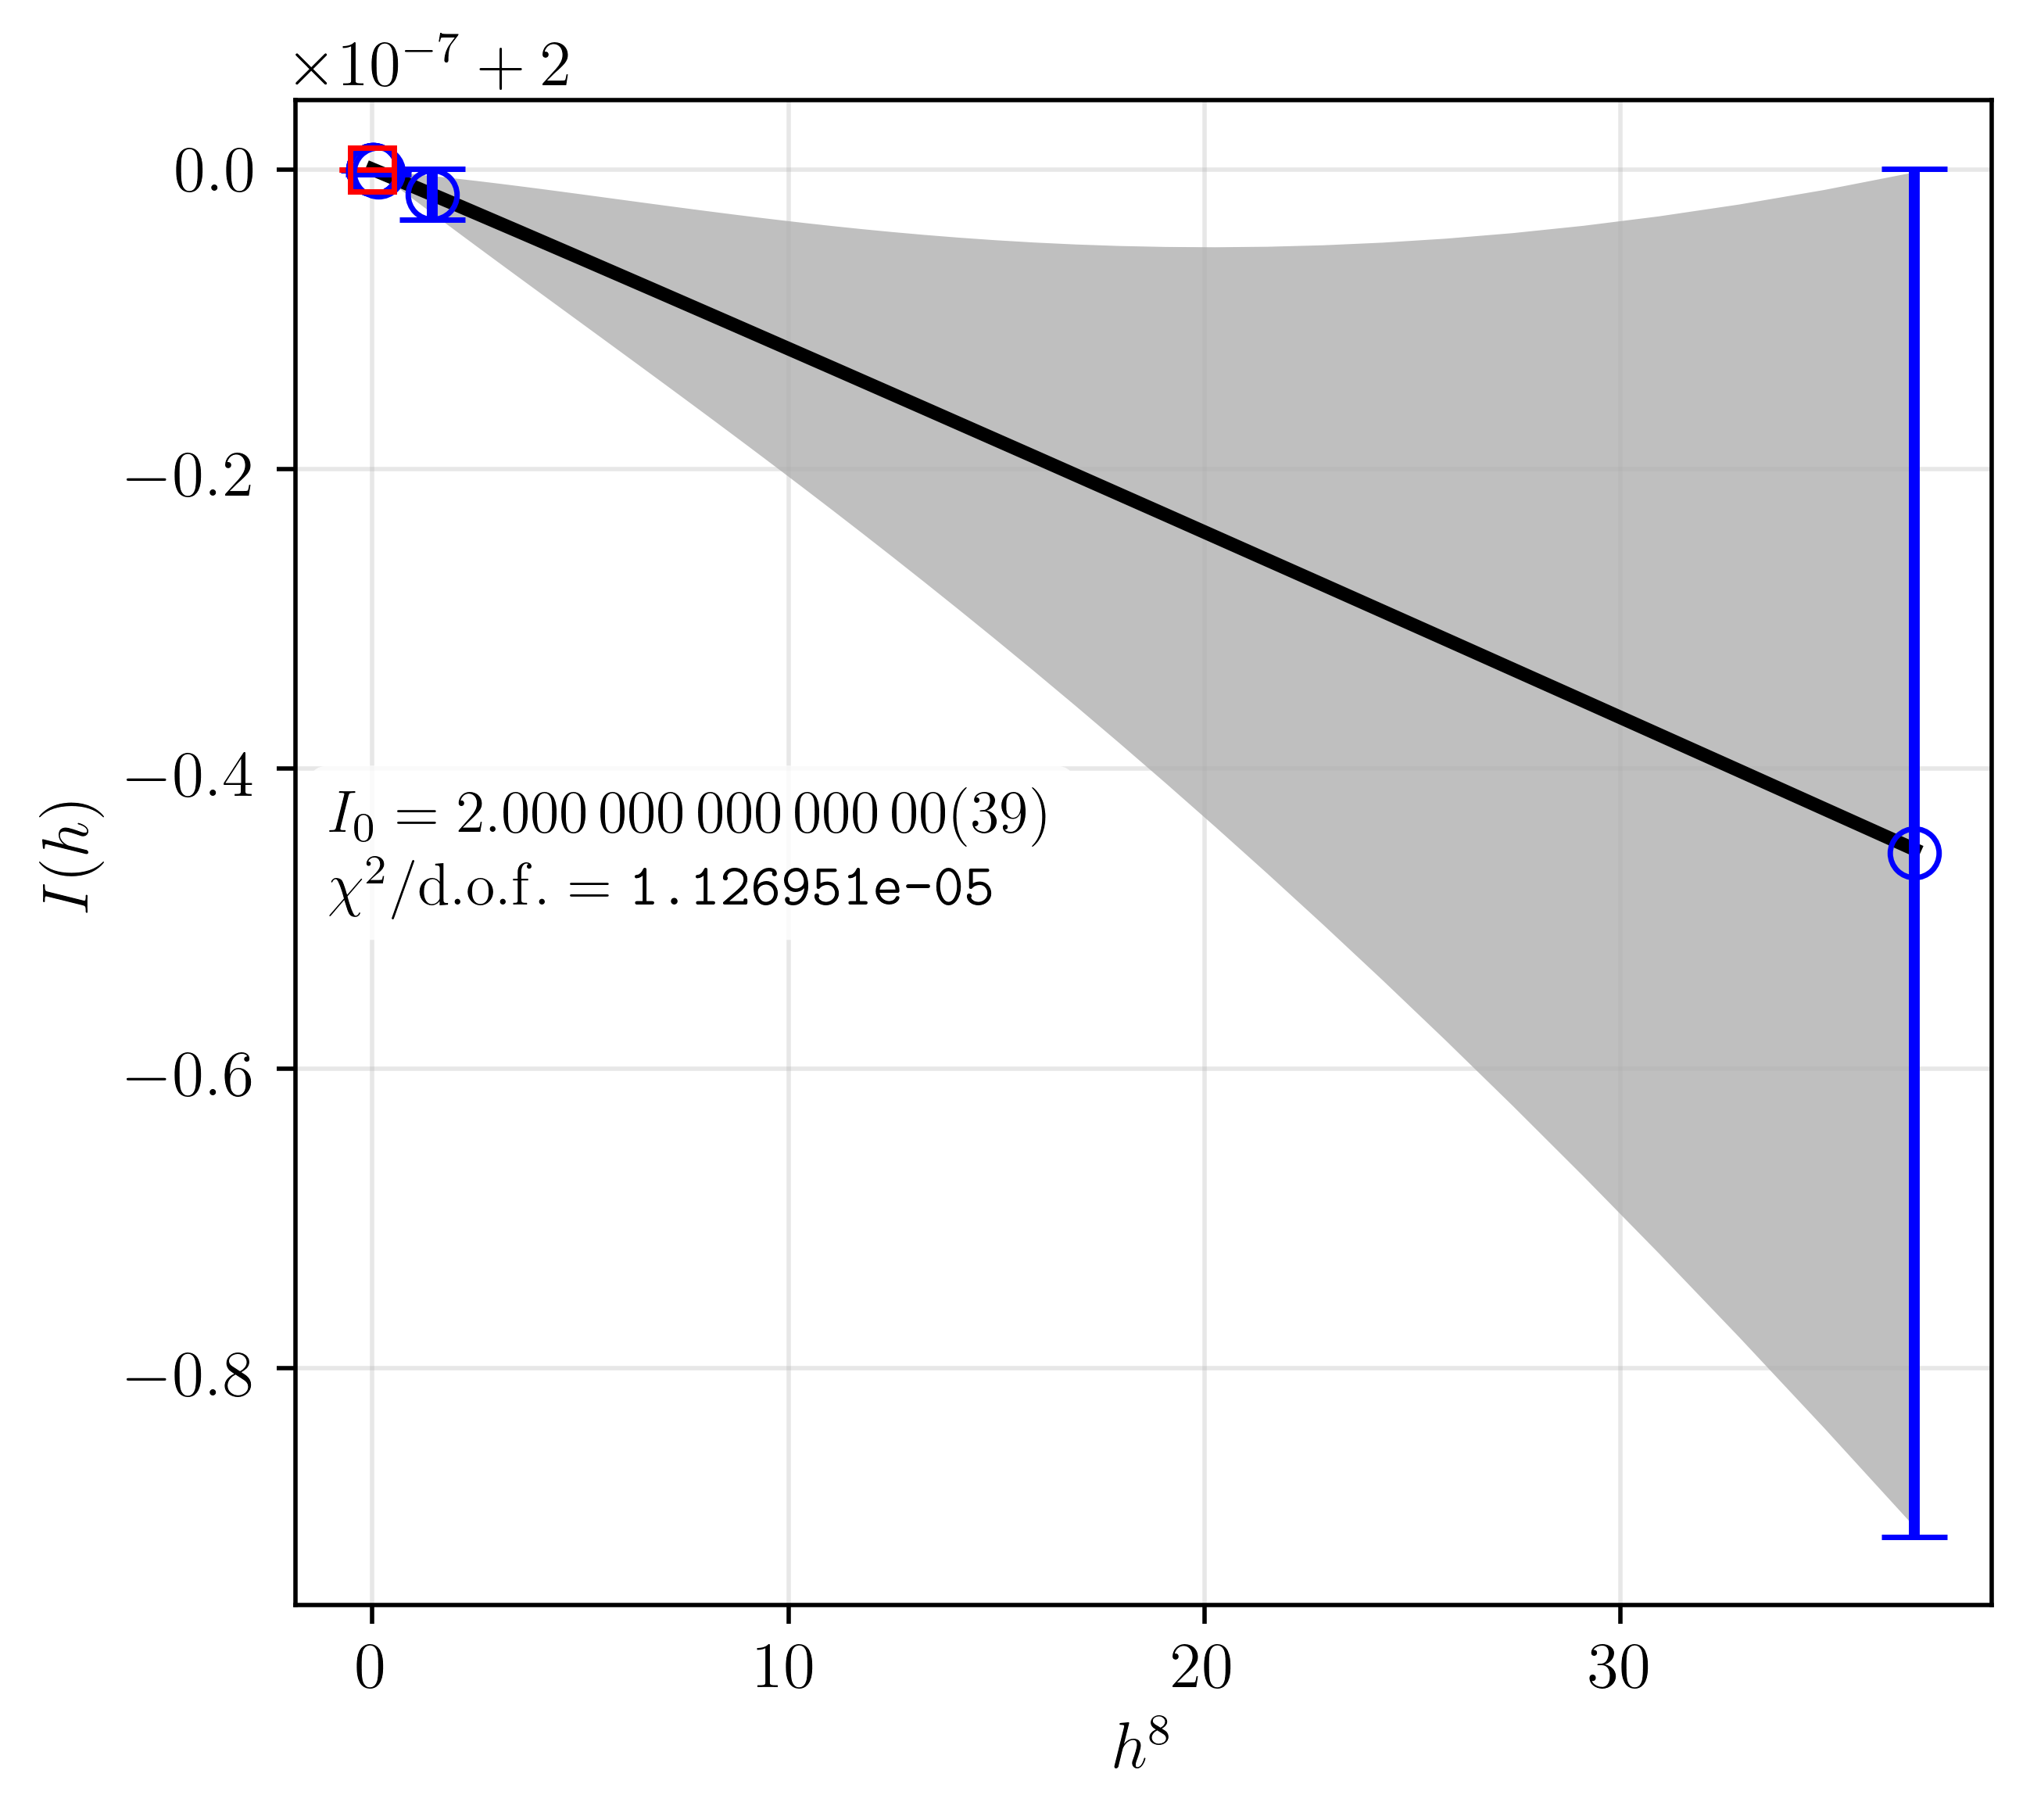

PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `./result_1D_gauss_p4_LU_EXEX_extrap-crop.pdf'.
PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `./result_1D_gauss_p4_LU_EXEX_reldiff-crop.pdf'.


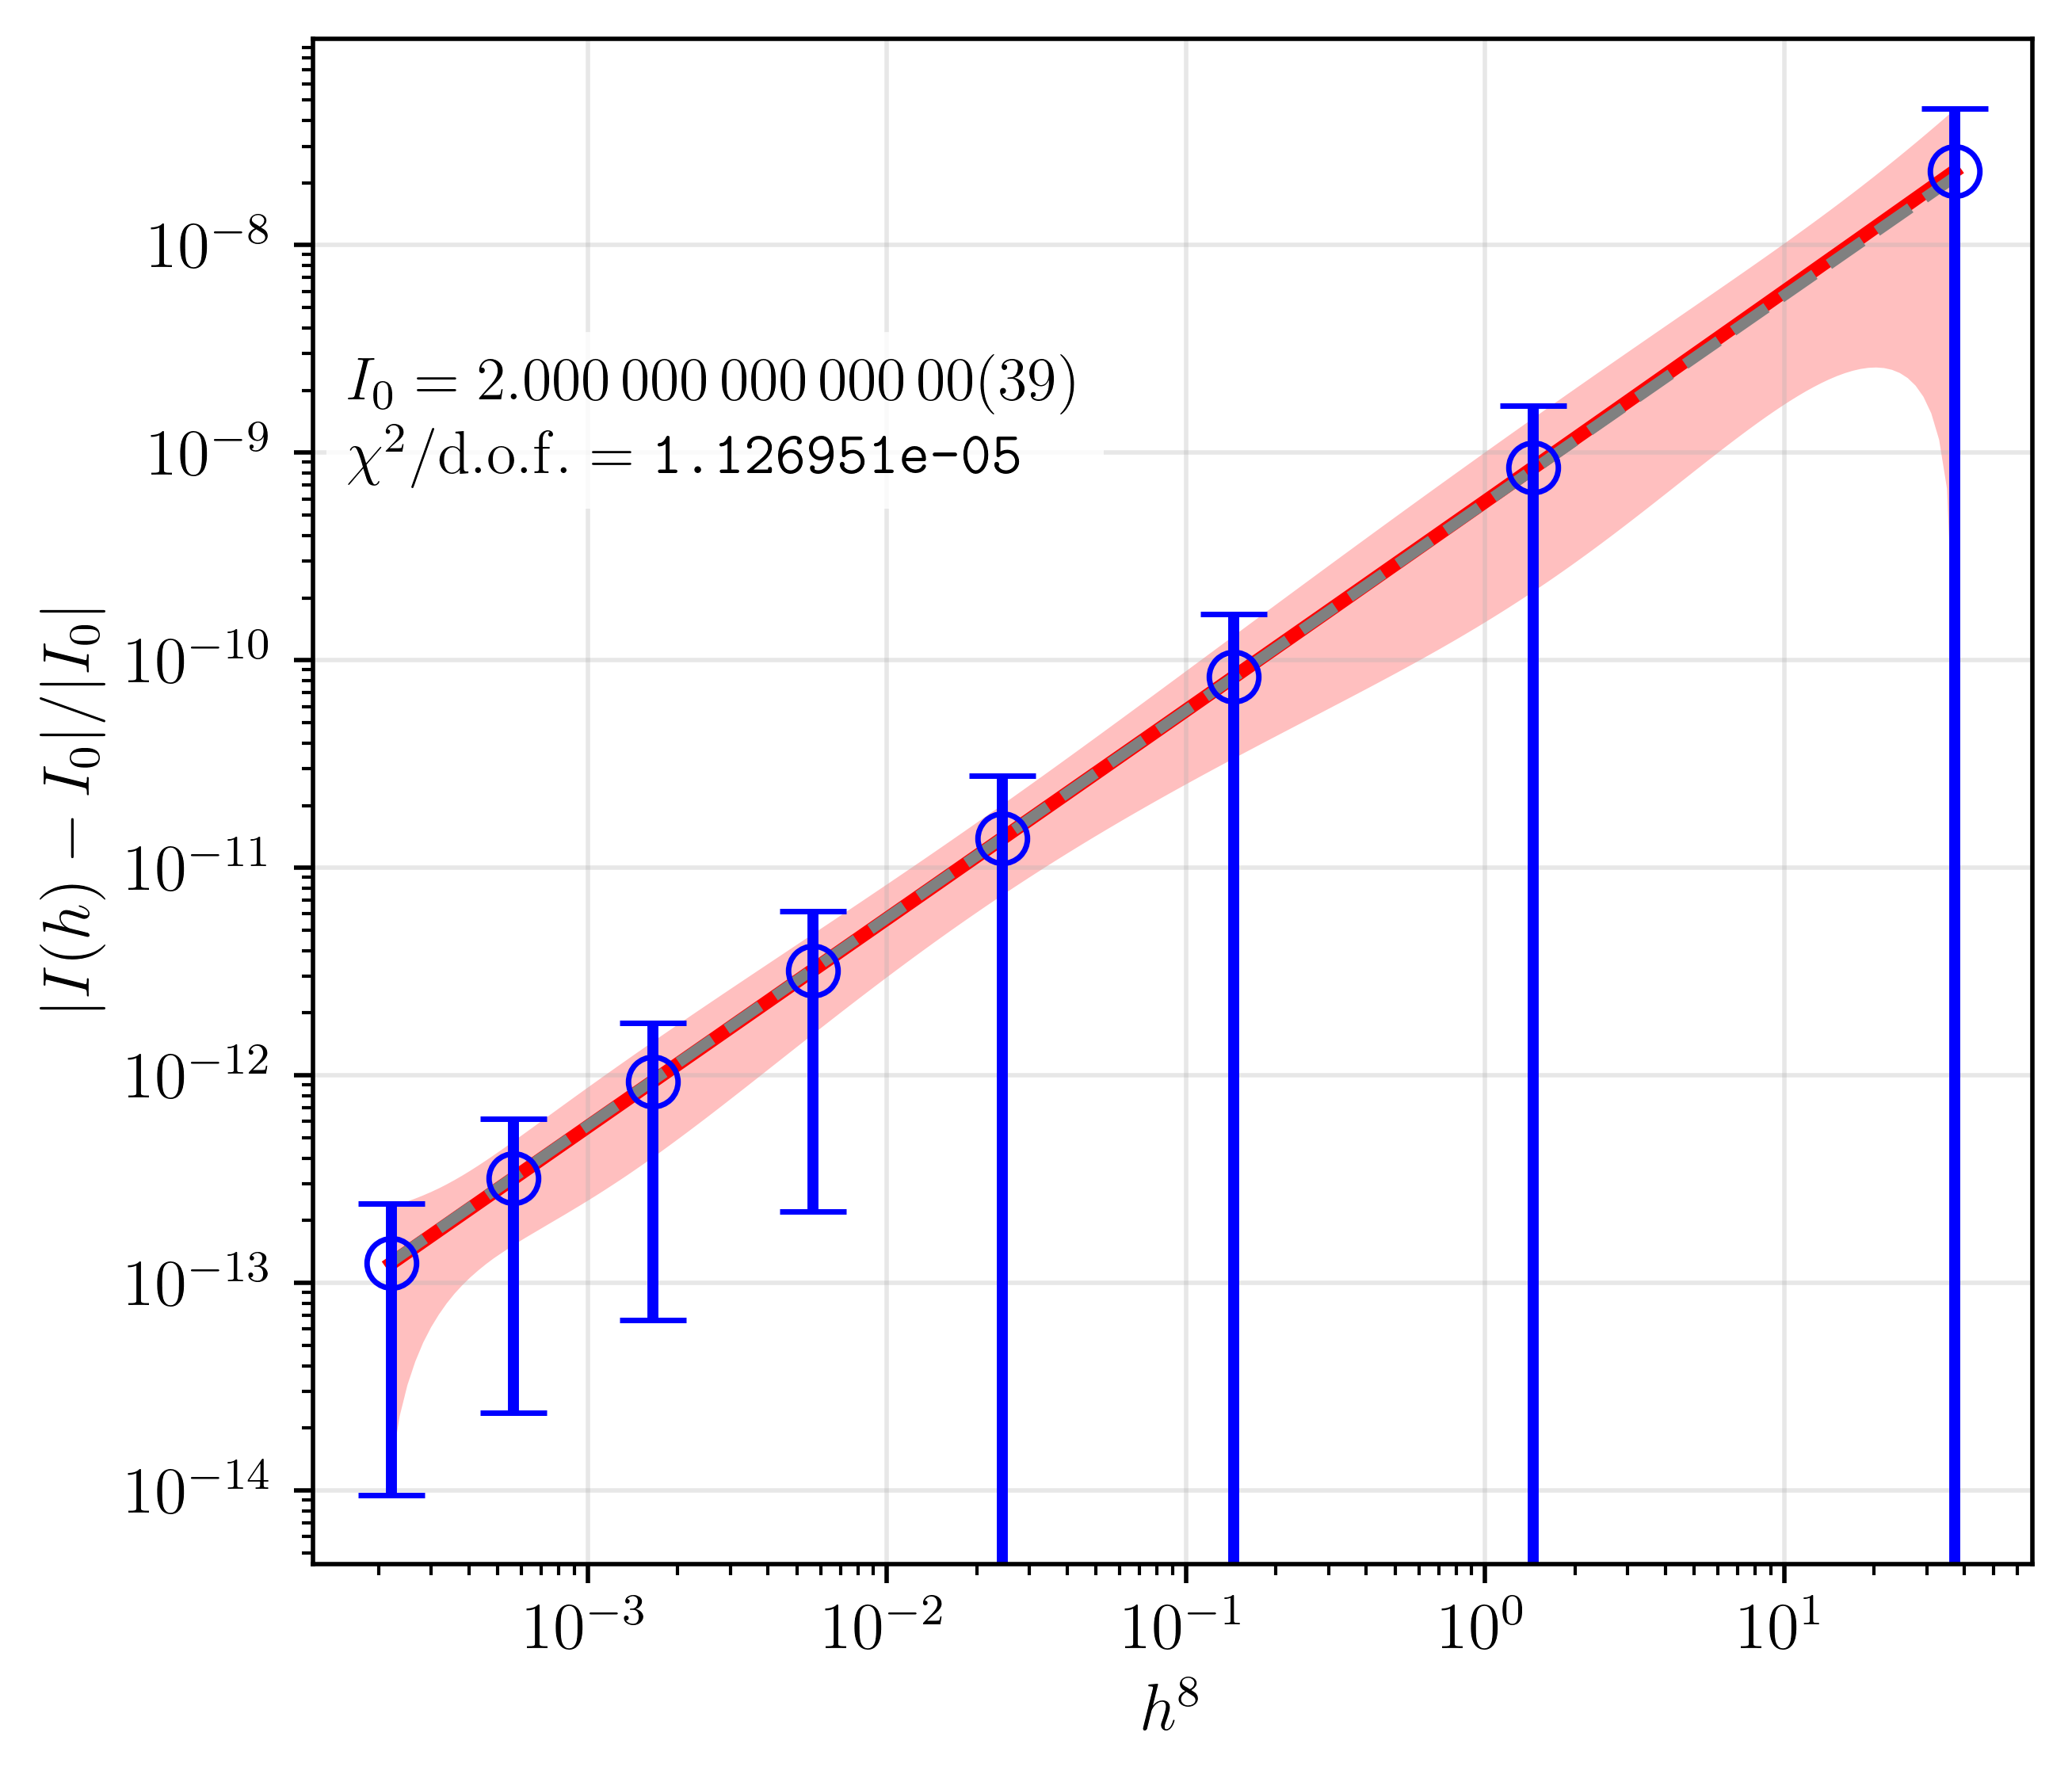

In [10]:
plot_convergence_result(
    bounds..., 
    result_string, 
    run_result_merged.h, 
    run_result_merged.avg, 
    run_result_merged.err, 
    fit_result_merged; 
    rule=rule, 
    boundary=boundary,
    save_file=save_file
)